In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
med_info = pd.read_csv("med_info.csv")

In [3]:
med_info.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [4]:
female_ABpos = med_info[(med_info["Gender"] == "Female") & (med_info["Blood Type"] == "AB+")]
prob = (female_ABpos["Medical Condition"] == "Diabetes").sum()/ len(female_ABpos) * 100
print(f"Probability: {round(prob, 1)}%")

Probability: 16.0%


In [5]:
admissions = med_info["Date of Admission"].value_counts()
min_count = admissions.min()
least_admitted = admissions[admissions == min_count]

print(least_admitted)
print(f"Minimum admissions on any date: {min_count}")
print(f"Number of dates with least admissions: {len(least_admitted)}")

Date of Admission
2021-02-26    1
2019-06-10    1
2020-07-11    1
2019-02-20    1
2022-10-28    1
2019-09-23    1
2019-11-14    1
2020-08-22    1
2021-10-03    1
2022-06-06    1
2020-07-22    1
2023-07-14    1
2019-11-24    1
2019-08-12    1
2022-05-03    1
2019-10-09    1
2022-01-12    1
2021-05-10    1
2020-05-01    1
2022-11-10    1
2021-05-28    1
2019-03-13    1
2023-06-07    1
2021-04-09    1
2019-10-19    1
2022-12-30    1
2022-12-11    1
2019-09-16    1
2020-12-02    1
2021-10-15    1
2019-11-05    1
2020-05-20    1
2021-02-20    1
2022-12-17    1
2022-07-16    1
2023-06-30    1
2022-06-11    1
2020-11-13    1
2021-01-14    1
2021-09-23    1
2023-02-11    1
2022-06-15    1
2021-03-05    1
2021-12-18    1
2018-11-12    1
2023-03-05    1
2020-09-20    1
2020-08-11    1
2020-07-03    1
Name: count, dtype: int64
Minimum admissions on any date: 1
Number of dates with least admissions: 49


                     Age  Billing Amount  Room Number
Age             1.000000       -0.009483    -0.005371
Billing Amount -0.009483        1.000000    -0.006160
Room Number    -0.005371       -0.006160     1.000000


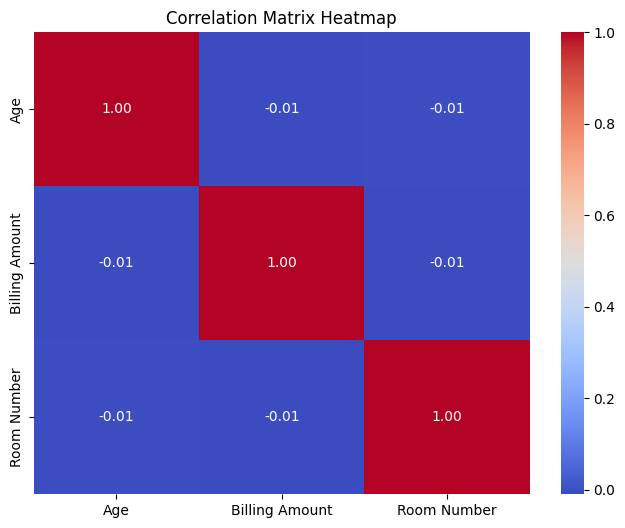

In [6]:
corr_matrix = med_info[["Age", "Billing Amount", "Room Number"]].corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [7]:
for col in med_info.columns:
    if med_info[col].dtype == object and med_info[col].nunique() > 10:
        med_info.drop(columns=[col], inplace=True)

print(f"Colunms: {med_info.columns}")

Colunms: Index(['Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type',
       'Medication', 'Test Results'],
      dtype='object')


In [8]:
med_info.drop(columns=["Insurance Provider", "Billing Amount", "Room Number"], inplace=True)
print(med_info.columns)

Index(['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Admission Type',
       'Medication', 'Test Results'],
      dtype='object')


In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
med_info["Test Results"] = le.fit_transform(med_info["Test Results"])
print(le.classes_) 

['Abnormal' 'Inconclusive' 'Normal']


In [10]:
med_info["Gender"] = med_info["Gender"].map({"Female": 0, "Male": 1})
print(med_info["Gender"])

0       0
1       1
2       1
3       1
4       1
       ..
9995    1
9996    0
9997    1
9998    1
9999    1
Name: Gender, Length: 10000, dtype: int64


In [11]:
med_info = pd.get_dummies(med_info, columns=["Blood Type", "Medical Condition", "Admission Type", "Medication"])
print(med_info.columns)

Index(['Age', 'Gender', 'Test Results', 'Blood Type_A+', 'Blood Type_A-',
       'Blood Type_AB+', 'Blood Type_AB-', 'Blood Type_B+', 'Blood Type_B-',
       'Blood Type_O+', 'Blood Type_O-', 'Medical Condition_Arthritis',
       'Medical Condition_Asthma', 'Medical Condition_Cancer',
       'Medical Condition_Diabetes', 'Medical Condition_Hypertension',
       'Medical Condition_Obesity', 'Admission Type_Elective',
       'Admission Type_Emergency', 'Admission Type_Urgent',
       'Medication_Aspirin', 'Medication_Ibuprofen', 'Medication_Lipitor',
       'Medication_Paracetamol', 'Medication_Penicillin'],
      dtype='object')


In [17]:
X = med_info.drop(columns=["Test Results"])
y = med_info["Test Results"] 

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 24)
y_train shape: (8000,)
X_test shape: (2000, 24)
y_test shape: (2000,)


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(gamma="auto")
}

In [23]:
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=10, scoring="accuracy")
    f1 = cross_val_score(model, X_train, y_train, cv=10, scoring="f1_weighted")
    print(f"{name}: Accuracy = {acc.mean():.4f}, F1 = {f1.mean():.4f}")

Naive Bayes: Accuracy = 0.3337, F1 = 0.3331
Logistic Regression: Accuracy = 0.3314, F1 = 0.3238
SVM: Accuracy = 0.3405, F1 = 0.3376


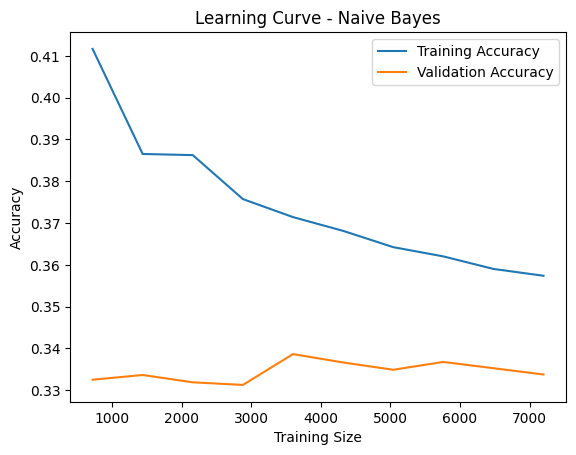

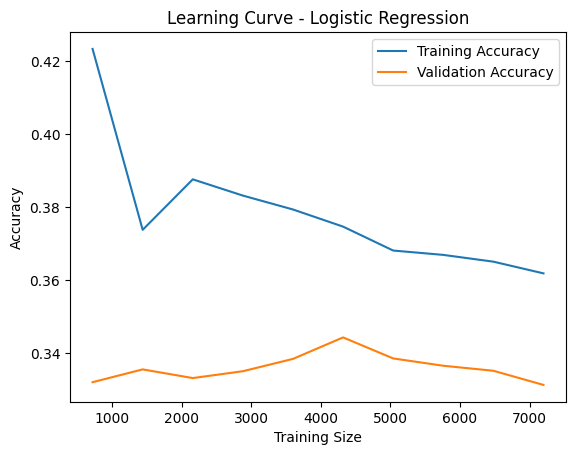

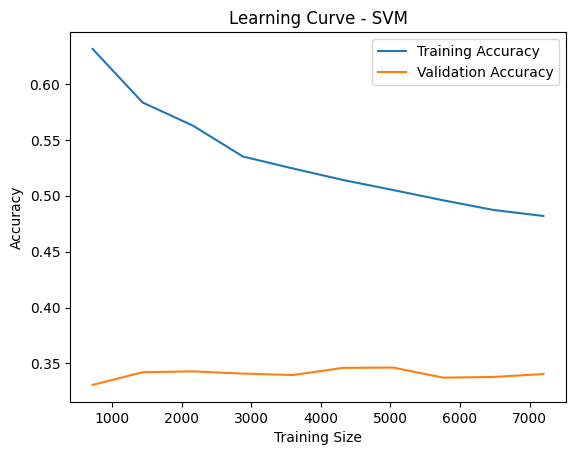

In [24]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, name, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=10, scoring="accuracy", 
        train_sizes=np.linspace(0.1, 1.0, 10))
    
    plt.figure()
    plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Accuracy")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Accuracy")
    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

for name, model in models.items():
    plot_learning_curve(model, name, X_train, y_train)

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_model = SVC(gamma="auto")
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [32]:
print("Test Accuracy:", accuracy_score(y_test , y_pred))

Test Accuracy: 0.337


In [34]:
print("Confusion Matrix:\n", confusion_matrix(y_test , y_pred ))
print("Classification Report:\n", classification_report(y_test , y_pred ))

Confusion Matrix:
 [[281 215 210]
 [263 183 190]
 [258 190 210]]
Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.40      0.37       706
           1       0.31      0.29      0.30       636
           2       0.34      0.32      0.33       658

    accuracy                           0.34      2000
   macro avg       0.34      0.33      0.33      2000
weighted avg       0.34      0.34      0.34      2000



All 3 models scored a an accuracy of about 33% but the highest was the SVM model. The learning curvs ahoed a gap between trainng and validation accuracy which indicates that the model was underfitting. This suggests that the features available in the dataset have a low predictive power over the Test results. The confusion matrix shows many misclassifications across the classes. I think the data was too noisy for this type of test and we need more cmoplex models.